In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
location = r"C:\Users\rajeshkumar.t\Desktop\ML\refund_risk_mgt.csv"
df= pd.read_csv(location)

In [3]:
print(df.columns)

Index(['pg_id', 'bank_name', 'parent_refund_id', 'created_hour',
       'refund_amount', 'status', 'is_stuck', 'age_minutes',
       'refund_reason_flag'],
      dtype='object')


In [4]:
le_dict = {}
for col in ['pg_id', 'bank_name','refund_reason_flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


In [5]:
X = df[['pg_id', 'bank_name', 'refund_reason_flag']]
y = df['is_stuck']

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size =0.2, random_state = 42)

    

In [6]:
model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
importances = model.feature_importances_
indices =np.argsort(importances)

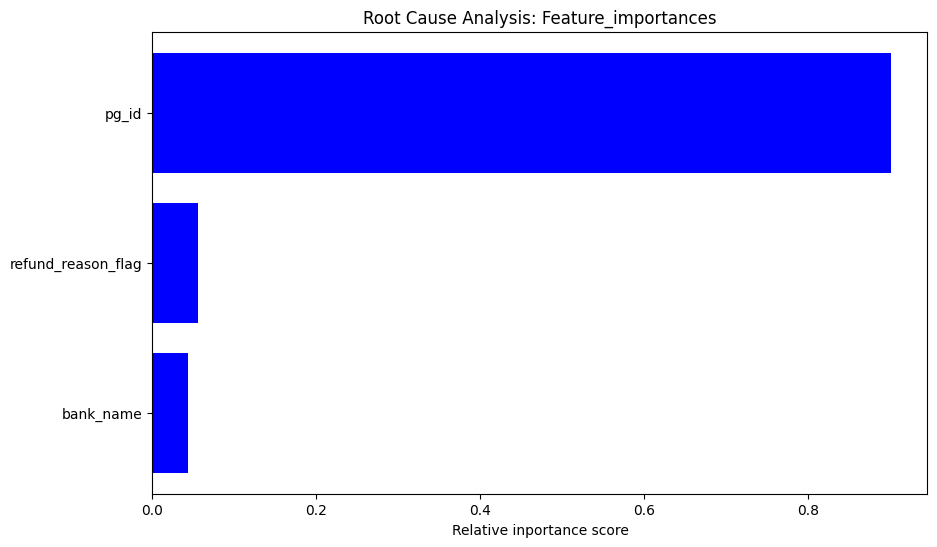

In [8]:
plt.figure(figsize=(10,6))
plt.title('Root Cause Analysis: Feature_importances')
plt.barh(range(len(indices)), importances[indices], color='b', align ='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative inportance score')
plt.show()

In [9]:
print("Machine Language Refences")
top_feature = X.columns[np.argmax(importances)]
print(f"1. Top Failure Driver: {top_feature}")
accuracy = model.score(X_test, y_test)
print(f" (2. Model Accuracy {round(accuracy * 100,2)}%")
print(f" (the model will correct predict of the refund fail {round(accuracy * 100,2)}%")


Machine Language Refences
1. Top Failure Driver: pg_id
 (2. Model Accuracy 99.93%
 (the model will correct predict of the refund fail 99.93%


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


<Figure size 600x600 with 0 Axes>

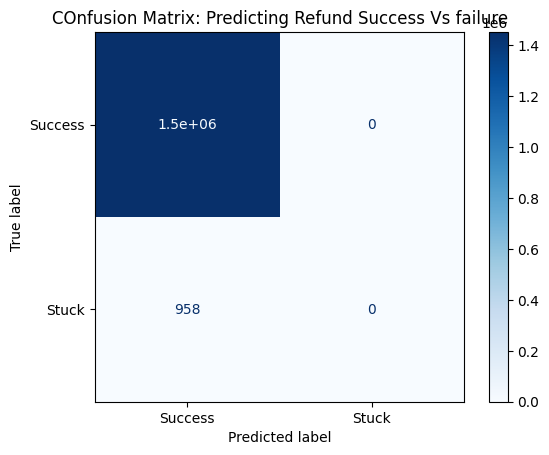

In [11]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Success', 'Stuck'])
disp.plot(cmap=plt.cm.Blues)
plt.title("COnfusion Matrix: Predicting Refund Success Vs failure")
plt.show()
                              

In [12]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes = np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

model = RandomForestClassifier(n_estimators= 100 , class_weight= class_weights, random_state= 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

<Figure size 600x600 with 0 Axes>

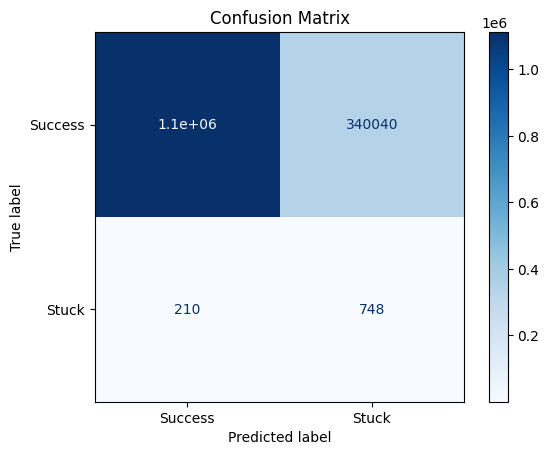

In [15]:
cm =confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Success', 'Stuck'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
                              

In [25]:
from sklearn.metrics import classification_report, f1_score, recall_score
y_true =[1] * 958 + [0] * 1440086
y_pred = [1] * 748 + [0] * 210 + [1] * 340040 + [0] * 1100046

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Recall Score: {round(recall * 100,2)}%")
print(f"F1 score: {round(f1 *100,2)}%")

print("\n--- Detailed Clasification Report ---")
print(classification_report(y_true, y_pred, target_names= ['Success', 'Stuck']))

                                                 

Recall Score: 78.08%
F1 score: 0.44%

--- Detailed Clasification Report ---
              precision    recall  f1-score   support

     Success       1.00      0.76      0.87   1440086
       Stuck       0.00      0.78      0.00       958

    accuracy                           0.76   1441044
   macro avg       0.50      0.77      0.44   1441044
weighted avg       1.00      0.76      0.87   1441044



In [27]:
y_pred = model.predict(X)
df['predicted_status'] = y_pred

true_positives = df[(df['is_stuck'] == 1) & (df['predicted_status'] ==1)]
rca_summary = true_positives.groupby(['pg_id', 'bank_name']).agg(
    impacted_refunds=('parent_refund_id', 'count'),
    total_value_at_risk=('refund_amount', 'sum'),
    avg_delay_minutes=('age_minutes','mean')).reset_index().sort_values(by='impacted_refunds' ,ascending=False)
print(rca_summary)

    
    

    pg_id  bank_name  impacted_refunds  total_value_at_risk  avg_delay_minutes
3      15        102              1610             81234000        2255.183851
13     34         29               470             35034800        3294.378723
14     34         72               333             16200900        2858.777778
41     62         72               232             11242300        2497.849138
39     62         29               174              4014900        2765.212644
..    ...        ...               ...                  ...                ...
40     62         43                 1                75400        2099.000000
63     97         84                 1              2484900        1973.000000
65    107         50                 1              1092600        2952.000000
67    108         36                 1                36100        1968.000000
70    108         63                 1                15000        4966.000000

[72 rows x 5 columns]


In [30]:
import os
desktop_path = os.path.join(os.path.join(os.path.expanduser('~')), 'Desktop')
final_path_file = os.path.join(desktop_path,"Final_Refund_RCA_Report.xlsx")
rca_summary.to_excel(final_path_file, index=False)
print(f"Success! your report is on destop as: {final_path_file}")

Success! your report is on destop as: C:\Users\rajeshkumar.t\Desktop\Final_Refund_RCA_Report.xlsx
